# DAY 2 | 초기 100사이클로 배터리 총수명 예측하기

**박진원 · 울산 1반 / 회귀 실습**

초기 100사이클 측정값으로 제공된 총수명 `cycle_life`를 예측했습니다.
수명이 몇 사이클인지와 오차 크기를 직접 비교하기 위해 회귀를 선택했습니다.
B1 개발용 28개에서 **113개 후보를 충전 방식별 3분할 교차검증(CV)**으로 비교해
**C037: Ridge, alpha=10, ln(수명), 입력 7개**를 선택했습니다.
모델을 고정한 뒤 확인한 MAPE는 **B1 별도 검증 8.44%, B2 55.22%**였습니다.
B1에서 오차가 작아도 다른 배치에서 잘 맞는다는 보장은 없었습니다.

이 노트북에서는 **저장된 학습 결과의 예측과 지표를 다시 확인**합니다.
저장 모델의 예측을 재현하며, `.fit()`이나 후보 재탐색은 실행하지 않습니다.
B2에서 오차가 더 작았던 모델로 최종 선택을 바꾸지도 않습니다.

| 수업 개념 | 여기서 확인하는 내용 |
|---|---|
| EDA → 입력 변수 설계 | ΔQ 추가, 중복 용량 변수 제외, ΔQ 평균·최솟값 대체 |
| 일반화·과적합 | CV / 별도 검증 / 다른 배치 테스트의 차이 |
| Pipeline | 결측값 대체와 표준화 기준을 각 학습 부분에서만 계산 |
| 회귀·규제·앙상블 | 평균 예측 / 선형회귀 / Ridge / Random Forest |
| 평가 지표 | MAPE, MAE, RMSE, R²와 퍼센트포인트 차이 |

**수명값의 차이:** B1은 용량이 80% 부근에서 기록이 끝나 제공된 값이고,
B2는 실제로 80% 아래로 내려간 시점을 확인한 값입니다. 이 차이를 그대로 남겼습니다.
DAY 1에서 B1 별도 검증용과 B2의 분포도 이미 살펴봤습니다.
B3는 DAY 1 EDA에 사용하고 이번 모델의 학습·평가에는 포함하지 않았습니다.

## 1. 결과 파일과 선택 기록 읽기

프로젝트 폴더 또는 `notebooks/`에서 실행할 수 있습니다.
데이터 다운로드나 학습을 자동으로 시작하지 않습니다.
결과 파일이 없다면 마지막 절의 **별도 작업 복제본에서 재현하는 방법**을 참고해 주세요.

In [1]:
from pathlib import Path
from datetime import datetime
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from IPython.display import display, Markdown
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge

%matplotlib inline
cwd = Path.cwd().resolve()
ROOT = next((p for p in [cwd, *cwd.parents]
             if (p / 'src/train_day2.py').is_file()
             and (p / 'data/processed/cells_analysis.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('프로젝트 또는 notebooks 폴더에서 실행하세요.')
OUT = ROOT / 'results/day2'
required = ['experiment_plan.json', 'selection_lock.json', 'evaluation.json',
            'cv_candidates.csv', 'cv_fold_metrics.csv', 'cv_oof_predictions.csv',
            'cv_assignments.csv', 'final_metrics.csv', 'final_predictions.csv',
            'fold_preprocessing_audit.json', 'final_preprocessing_audit.json',
            'feature_range_shift.json', 'subgroup_errors.csv', 'random_cv_sensitivity.csv']
missing = [name for name in required if not (OUT / name).is_file()]
if missing:
    raise FileNotFoundError('학습 결과가 필요합니다. 자동 재학습하지 않습니다: ' + ', '.join(missing))
load_json = lambda name: json.loads((OUT / name).read_text())
sha = lambda path: hashlib.sha256(Path(path).read_bytes()).hexdigest()
plan = load_json('experiment_plan.json')
lock = load_json('selection_lock.json')
evaluation = load_json('evaluation.json')
data = pd.read_csv(ROOT / 'data/processed/cells_analysis.csv')
cv = pd.read_csv(OUT / 'cv_candidates.csv')
folds = pd.read_csv(OUT / 'cv_fold_metrics.csv')
oof = pd.read_csv(OUT / 'cv_oof_predictions.csv')
assignments = pd.read_csv(OUT / 'cv_assignments.csv')
reported = pd.read_csv(OUT / 'final_metrics.csv')
predictions = pd.read_csv(OUT / 'final_predictions.csv')
winner = lock['winner_id']
spec = lock['specs'][winner]
features = lock['feature_sets'][spec['feature_set']]
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 65)
plt.rcParams.update({'figure.dpi': 115, 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titlesize': 12})
print('프로젝트:', ROOT)
print('고정된 선택:', winner, spec)
print('모델 학습은 다시 실행하지 않습니다.')

Matplotlib is building the font cache; this may take a moment.


프로젝트: /Users/jinwon/workspace/데이터 분석 미니플젝
고정된 선택: C037 {'family': 'Ridge', 'feature_set': 'no_qd_change7', 'params': {'alpha': 10.0}, 'target_transform': 'log', 'id': 'C037'}
모델 학습은 다시 실행하지 않습니다.


In [2]:
# 해시가 같으면 선택 당시와 동일한 파일 바이트임을 확인할 수 있다.
assert lock['source_sha256'] == plan['source_sha256']
for relative, expected in lock['source_sha256'].items():
    assert sha(ROOT / relative) == expected, relative
assert sha(OUT / 'experiment_plan.json') == lock['plan_sha256']
assert sha(OUT / 'cv_candidates.csv') == lock['cv_results_sha256']
assert sha(OUT / 'selection_lock.json') == evaluation['selection_lock_sha256']
assert sha(ROOT / 'src/train_day2.py') == lock['training_source_sha256']
for candidate_id, expected in lock['model_sha256'].items():
    assert sha(OUT / 'models' / f'{candidate_id}.joblib') == expected, candidate_id
assert datetime.fromisoformat(plan['created_at']) < datetime.fromisoformat(lock['locked_at'])
assert datetime.fromisoformat(lock['locked_at']) < datetime.fromisoformat(evaluation['evaluated_at'])
assert winner == evaluation['winner_id'] == 'C037'
assert evaluation['post_test_tuning'] is False
assert evaluation['batch3_model_evaluation'] is False
protected = [OUT / name for name in required]
protected += [OUT / 'models' / f'{cid}.joblib' for cid in lock['specs']]
protected += [ROOT / rel for rel in lock['source_sha256']]
before_hashes = {str(p.relative_to(ROOT)): sha(p) for p in protected}
display(pd.DataFrame([
    {'단계': '계획 저장', '시각 UTC': plan['created_at']},
    {'단계': 'CV로 모델 선택 고정', '시각 UTC': lock['locked_at']},
    {'단계': 'Valid/Test 평가', '시각 UTC': evaluation['evaluated_at']},
]))
print('입력·계획·CV 결과·저장 모델의 해시와 단계 순서가 일치합니다.')

,단계,시각 UTC
0,계획 저장,2026-10-01T04:32:41.503365+00:00
1,CV로 모델 선택 고정,2026-10-01T04:32:48.938988+00:00
2,Valid/Test 평가,2026-10-01T04:33:09.479624+00:00


입력·계획·CV 결과·저장 모델의 해시와 단계 순서가 일치합니다.


## 2. 배터리 셀 단위로 데이터를 나눴습니다

사이클 행을 무작위로 나누면 같은 배터리의 기록이 학습과 검증에 함께 들어갈 수 있습니다.
여기서는 **셀 기록 단위**로 B1 개발용 28개 / B1 별도 검증용 8개 / B2 테스트 39개를 나눴습니다.
다만 원본 barcode를 해독하지 못해 물리적으로 같은 셀이 있는지까지 완전히 확인한 것은 아닙니다.
최종 모델은 개발용 28개로 학습했으며 별도 검증용 8개를 합쳐 다시 학습하지 않았습니다.

`Train (Batch1 CV)`는 과제 성능표의 이름입니다.
학습 데이터를 다시 예측한 점수가 아니라, 학습에서 빼 둔 부분을 예측한 **3개 검증 점수의 평균**입니다.

In [3]:
roles = {'Batch1_CV_development': 'B1 개발', 'Batch1_holdout': 'B1 holdout',
         'Batch2_final_test': 'B2 Test', 'Batch3_EDA_only': 'B3 EDA 전용',
         'excluded': '분석 제외'}
dev = data.loc[data.split_role.eq('Batch1_CV_development')].copy()
valid = data.loc[data.split_role.eq('Batch1_holdout')].copy()
test = data.loc[data.split_role.eq('Batch2_final_test')].copy()
assert [len(dev), len(valid), len(test)] == [28, 8, 39]
assert set(dev.cell_id) == set(lock['training_ids'])
sets = [set(frame.cell_id) for frame in [dev, valid, test]]
assert not (sets[0] & sets[1] or sets[0] & sets[2] or sets[1] & sets[2])
split_table = data.groupby('split_role').agg(셀수=('cell_id', 'size')).rename(index=roles)
display(split_table)
display(pd.DataFrame([
    {'구분': name, 'n': len(frame), '수명 최소': frame.cycle_life.min(),
     '수명 중앙값': frame.cycle_life.median(), '수명 최대': frame.cycle_life.max(),
     '라벨 종류': ', '.join(frame.label_status.unique())}
    for name, frame in [('B1 개발', dev), ('B1 holdout', valid), ('B2 Test', test)]
]))

,셀수
split_role,
B1 개발,28
B1 holdout,8
B2 Test,39
B3 EDA 전용,40
분석 제외,24


,구분,n,수명 최소,수명 중앙값,수명 최대,라벨 종류
0,B1 개발,28,534.0,749.5,1074.0,provided_near80_endpoint_proxy
1,B1 holdout,8,559.0,873.0,1051.0,provided_near80_endpoint_proxy
2,B2 Test,39,392.0,472.0,1186.0,observed_80pct_crossing


## 3. DAY 1에서 본 내용을 입력 조합으로 옮겼습니다

ΔQ 분산은 수명과 관련됐고, 용량 변화량과 기울기는 상관계수 0.985로 비슷한 정보를 담고 있었습니다.
이를 **ΔQ 추가 / 중복 변수 제외 / ΔQ 평균·최솟값 대체 / 저항 제외 / ΔQ 단독** 비교로 이어 갔습니다.
각 변수는 초기 100사이클 이내에서 계산했습니다. 전체 수명, 종료 용량, knee 위치는 입력에 넣지 않았습니다.

충전 시간은 초기 2-100사이클 중 `0 < chargetime < 120`인 값만 평균에 사용했습니다.
분석 대상 셀에서 B1 3개·B2 10개의 측정값이 제외됐으며 셀은 제외하지 않았습니다.
큰 값이 평균에 미치는 영향을 줄이기 위한 잠정 기준이며, 큰 값이 발생한 원인은 확인하지 못했습니다.

113개는 모델 이름의 수가 아니라 **입력 조합 × 모델 × 설정 × 수명값 변환**을 합친 후보 수입니다.
선형회귀·Ridge는 원래 수명과 ln(수명)을 비교했고, Ridge alpha는 0.1/1/10/100으로 정했습니다.
Random Forest는 나무 300개, 깊이 3/제한 없음, 끝 노드의 최소 표본 수 1/3,
max_features=1.0, seed=42를 사용했습니다. RF에는 수명값 변환을 적용하지 않았습니다.
전체 후보는 평균 예측 1개 + 선형회귀 16개 + Ridge 64개 + Random Forest 32개로, 모두 113개입니다.

In [4]:
definitions = {
    'qd_cycle2': '2사이클 방전용량(Ah)',
    'qd_change_100_10': 'QD100-QD10(Ah)',
    'qd_slope_10_100': '10~100사이클 QD 직선 기울기(Ah/cycle)',
    'ir_mean_2_100': '2~100사이클 양의 내부저항 평균',
    'ir_change_early': '양의 IR 측정값으로 구한 91~100사이클 평균 - 2~10사이클 평균',
    'tavg_mean_2_100': '2~100사이클 유효 평균온도',
    'chargetime_mean_2_100': '2~100사이클 유효 충전시간 평균',
    'log10_deltaq_var': 'log10 Var[Q100(V)-Q10(V)], ddof=1',
    'deltaq_mean': '평균[Q100(V)-Q10(V)]',
    'deltaq_min': '최소[Q100(V)-Q10(V)]',
}
feature_sets = pd.DataFrame([
    {'집합': name, '특성 수': len(fs), '특성': ', '.join(fs),
     '최종 선택': name == spec['feature_set']}
    for name, fs in lock['feature_sets'].items()
])
display(feature_sets)
display(pd.DataFrame({'선택한 7개 특성': features,
                      '정의': [definitions[f] for f in features]}))
candidate_counts = cv.groupby('family').size().rename('후보 수')
display(candidate_counts.to_frame())
assert len(cv) == len(plan['candidates']) == 113
assert not set(features) & {'cycle_life', 'n_summary', 'last_qd', 'first_below_80'}

,집합,특성 수,특성,최종 선택
0,basic7,7,"qd_cycle2, qd_change_100_10, qd_slope_10_100, ir_mean_2_100, ...",False
1,deltaq8,8,"qd_cycle2, qd_change_100_10, qd_slope_10_100, ir_mean_2_100, ...",False
2,no_qd_change7,7,"qd_cycle2, qd_slope_10_100, ir_mean_2_100, ir_change_early, t...",True
3,no_qd_slope7,7,"qd_cycle2, qd_change_100_10, ir_mean_2_100, ir_change_early, ...",False
4,deltaq_mean8,8,"qd_cycle2, qd_change_100_10, qd_slope_10_100, ir_mean_2_100, ...",False
5,deltaq_min8,8,"qd_cycle2, qd_change_100_10, qd_slope_10_100, ir_mean_2_100, ...",False
6,no_ir6,6,"qd_cycle2, qd_change_100_10, qd_slope_10_100, tavg_mean_2_100...",False
7,deltaq_only1,1,log10_deltaq_var,False


,선택한 7개 특성,정의
0,qd_cycle2,2사이클 방전용량(Ah)
1,qd_slope_10_100,10~100사이클 QD 직선 기울기(Ah/cycle)
2,ir_mean_2_100,2~100사이클 양의 내부저항 평균
3,ir_change_early,양의 IR 측정값으로 구한 91~100사이클 평균 - 2~10사이클 평균
4,tavg_mean_2_100,2~100사이클 유효 평균온도
5,chargetime_mean_2_100,2~100사이클 유효 충전시간 평균
6,log10_deltaq_var,"log10 Var[Q100(V)-Q10(V)], ddof=1"


,후보 수
family,
Dummy,1
Linear,16
RandomForest,32
Ridge,64


## 4. 충전 방식을 분리하고 전처리 기준을 확인했습니다

같은 충전 방식의 셀이 학습·검증에 함께 들어가지 않도록 **같은 `policy` 문자열을 한 그룹**으로 묶었습니다.
개발용의 18개 그룹을 `GroupKFold(3)`로 나눴습니다.
비슷한 충전 방식이라도 이름이 다르면 자동으로 같은 그룹이 되지는 않습니다.
별도 검증용은 셀 ID가 다르지만, 8개 중 5개는 개발용과 충전 방식이 같습니다.

결측값을 채울 중앙값과 표준화에 쓸 평균·표준편차는 **각 fold의 학습 데이터만** 보고 구했습니다.
이 순서를 `Pipeline`으로 묶었습니다.
아래에서는 저장된 전처리 기준이 해당 학습 셀에서 계산한 값과 같은지 확인합니다.

In [5]:
fold_summary = []
for k, group in assignments.groupby('fold'):
    tr = group.loc[group.role.eq('train')]
    va = group.loc[group.role.eq('validation')]
    assert not set(tr.cell_id) & set(va.cell_id)
    assert not set(tr.policy) & set(va.policy)
    assert set(tr.cell_id) | set(va.cell_id) == set(dev.cell_id)
    fold_summary.append({'fold': k, '학습 셀': len(tr), '검증 셀': len(va),
                         '학습 정책': tr.policy.nunique(), '검증 정책': va.policy.nunique(),
                         '정책 중복': len(set(tr.policy) & set(va.policy))})
assert assignments.loc[assignments.role.eq('validation')].cell_id.value_counts().eq(1).all()
assert dev.policy.nunique() == 18
display(pd.DataFrame(fold_summary))
print('별도 holdout의 개발 정책 공유 셀:', valid.policy.isin(dev.policy).sum(), '/', len(valid))

audit = load_json('fold_preprocessing_audit.json')
by_id = dev.set_index('cell_id')
for row in audit:
    fs = row['feature_names']
    training = by_id.loc[row['train_ids'], fs]
    medians = training.median().to_numpy()
    assert np.allclose(medians, row['imputer_statistics'], equal_nan=True)
    if row['scaler_mean'] is not None:
        expected = training.fillna(training.median()).mean().to_numpy()
        assert np.allclose(expected, row['scaler_mean'])
    assert not set(row['train_ids']) & set(row['validation_ids'])
print(f'{len(audit)}개 후보×fold 전처리 기록: 학습 fold 중앙값·평균 검증 통과')

,fold,학습 셀,검증 셀,학습 정책,검증 정책,정책 중복
0,1,18,10,12,6,0
1,2,19,9,12,6,0
2,3,19,9,12,6,0


별도 holdout의 개발 정책 공유 셀: 5 / 8
339개 후보×fold 전처리 기록: 학습 fold 중앙값·평균 검증 통과


선택한 모델은 **중앙값 대체 → 표준화 → ln(수명)에 Ridge 학습 → exp로 사이클 수 복원** 순서입니다.
`alpha=10`은 계수가 지나치게 커지지 않도록 하는 규제 강도입니다.
입력을 표준화하는 것과 수명값에 로그를 적용하는 것은 서로 다른 처리입니다.
`TransformedTargetRegressor`는 자연로그 `ln(y)`를 학습하고, 예측할 때 `exp`로 원래 사이클 수로 되돌립니다.

모델은 ln(수명)의 제곱오차를 줄이도록 학습했습니다. MAPE를 직접 최소화하며 학습한 것은 아닙니다.
후보 선택에는 원래 사이클 수로 복원한 예측의 MAPE를 사용했습니다.
예측값을 잘라 내거나 테스트 결과에 맞춰 추가 보정하지 않았습니다.

In [6]:
# 저장 모델은 위에서 해시를 확인한 로컬 학습 산출물이다. fit() 없이 읽는다.
selected_model = joblib.load(OUT / 'models' / f'{winner}.joblib')
print(selected_model)
assert list(selected_model.named_steps) == ['imputer', 'scaler', 'model']
transformer = selected_model.named_steps['model']
assert isinstance(transformer, TransformedTargetRegressor)
assert isinstance(transformer.regressor_, Ridge)
assert transformer.regressor_.alpha == 10
assert spec['target_transform'] == 'log'
assert np.allclose(selected_model.named_steps['imputer'].statistics_, dev[features].median())
assert np.allclose(selected_model.named_steps['scaler'].mean_, dev[features].mean())
assert int(selected_model.named_steps['scaler'].n_samples_seen_) == 28
print('최종 전처리도 개발 28셀에서 계산한 값과 일치합니다.')

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 TransformedTargetRegressor(func=<ufunc 'log'>,
                                            inverse_func=<ufunc 'exp'>,
                                            regressor=Ridge(alpha=10.0)))])
최종 전처리도 개발 28셀에서 계산한 값과 일치합니다.


## 5. 저장된 예측에서 평가 지표를 계산했습니다

- **MAPE(%)**는 `평균(|예측-실제| / 실제) × 100`입니다. 같은 사이클 오차라도 실제 수명이 짧으면 비율이 커집니다.
  55%는 틀린 셀의 비율이 아니라 셀별 상대오차의 평균입니다.
- **MAE**는 평균적으로 몇 사이클 빗나갔는지 보여 줍니다.
- **RMSE**는 큰 오차의 영향을 더 크게 반영합니다.
- **R²**는 평가 집단의 실제 평균 수명을 기준으로 제곱오차를 비교하며, 음수도 나올 수 있습니다.
  이 기준은 B1 학습 평균을 사용하는 평균 예측 모델과 다릅니다.

아래 함수에서는 NumPy 공식으로 지표를 다시 계산합니다.
CV의 검증 셀 수가 10/9/9이므로 **fold 점수의 단순 평균**과 모든 검증 예측을 합친 점수는 조금 다를 수 있습니다.
선택에는 계획대로 fold 단순 평균을 사용했습니다. CV 표준편차는 3개 fold 점수의 퍼짐이며 신뢰구간은 아닙니다.

In [7]:
def independent_metrics(y, pred):
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)
    assert np.isfinite(y).all() and np.isfinite(pred).all() and (y > 0).all()
    error = pred - y
    return {'mape_pct': np.mean(np.abs(error) / y) * 100,
            'mae_cycles': np.mean(np.abs(error)),
            'rmse_cycles': np.sqrt(np.mean(error ** 2)),
            'r2': 1 - np.sum(error ** 2) / np.sum((y - y.mean()) ** 2)}

metric_names = ['mape_pct', 'mae_cycles', 'rmse_cycles', 'r2']
recalculated_cv = []
for (cid, k), group in oof.groupby(['candidate_id', 'fold']):
    metrics = independent_metrics(group.actual, group.predicted)
    saved = folds.loc[folds.candidate_id.eq(cid) & folds.fold.eq(k)].iloc[0]
    assert np.allclose([metrics[m] for m in metric_names], saved[metric_names].to_numpy(float))
    recalculated_cv.append({'candidate_id': cid, 'fold': k, **metrics})
recalculated_cv = pd.DataFrame(recalculated_cv)
cv_summary = recalculated_cv.groupby('candidate_id').mape_pct.agg(['mean', 'std'])
recorded = cv.set_index('candidate_id')
assert np.allclose(cv_summary['mean'], recorded.loc[cv_summary.index, 'cv_mape_pct_mean'])
assert np.allclose(cv_summary['std'], recorded.loc[cv_summary.index, 'cv_mape_pct_sd'])
ranked = cv.sort_values(['cv_mape_pct_mean', 'candidate_id'])
assert ranked.iloc[0].candidate_id == winner
for family, cid in lock['family_winners'].items():
    assert ranked.loc[ranked.family.eq(family)].iloc[0].candidate_id == cid
print('113개 후보 × 3-fold 지표를 예측에서 재계산했고 선택 순위도 일치합니다.')
display(ranked[['candidate_id', 'family', 'feature_set', 'target_transform', 'params',
                'cv_mape_pct_mean', 'cv_mape_pct_sd']].head(12).round(3))

113개 후보 × 3-fold 지표를 예측에서 재계산했고 선택 순위도 일치합니다.


,candidate_id,family,feature_set,target_transform,params,cv_mape_pct_mean,cv_mape_pct_sd
0,C037,Ridge,no_qd_change7,log,"{""alpha"": 10.0}",8.228,1.326
1,C032,Ridge,no_qd_change7,raw,"{""alpha"": 10.0}",8.813,1.214
2,C051,Ridge,no_qd_slope7,log,"{""alpha"": 10.0}",8.871,0.907
3,C092,Ridge,no_ir6,log,"{""alpha"": 1.0}",9.076,3.165
4,C106,Ridge,deltaq_only1,log,"{""alpha"": 1.0}",9.088,1.130
5,C105,Ridge,deltaq_only1,log,"{""alpha"": 0.1}",9.242,1.535
6,C104,Linear,deltaq_only1,log,{},9.260,1.586
7,C091,Ridge,no_ir6,log,"{""alpha"": 0.1}",9.301,3.599
8,C101,Ridge,deltaq_only1,raw,"{""alpha"": 1.0}",9.369,1.354
9,C100,Ridge,deltaq_only1,raw,"{""alpha"": 0.1}",9.533,1.828


,fold,train_n,valid_n,train_fit_mape_pct,mape_pct,mae_cycles,rmse_cycles,r2
111,1,18,10,8.032,7.263,56.039,72.828,0.729
112,2,19,9,7.551,7.682,57.522,62.650,0.685
113,3,19,9,7.399,9.740,83.643,102.160,0.344


선택 기준: fold MAPE 단순 평균 8.2285%
참고만: 28개 OOF 전체 MAPE 8.1940%


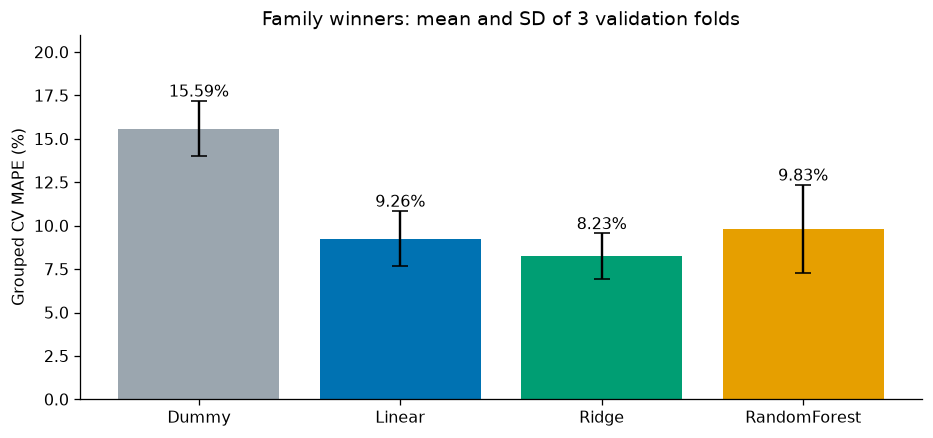

In [8]:
winner_folds = folds.loc[folds.candidate_id.eq(winner)]
display(winner_folds[['fold', 'train_n', 'valid_n', 'train_fit_mape_pct',
                      'mape_pct', 'mae_cycles', 'rmse_cycles', 'r2']].round(3))
pooled = oof.loc[oof.candidate_id.eq(winner)]
print(f'선택 기준: fold MAPE 단순 평균 {winner_folds.mape_pct.mean():.4f}%')
print(f'참고만: 28개 OOF 전체 MAPE {independent_metrics(pooled.actual, pooled.predicted)["mape_pct"]:.4f}%')
family_cv = ranked.loc[ranked.candidate_id.isin(lock['family_winners'].values())].copy()
family_cv = family_cv.set_index('family').loc[['Dummy', 'Linear', 'Ridge', 'RandomForest']]
fig, ax = plt.subplots(figsize=(8, 3.7), layout='constrained')
ax.bar(family_cv.index, family_cv.cv_mape_pct_mean,
       yerr=family_cv.cv_mape_pct_sd, capsize=5,
       color=['#9BA6AF', '#0072B2', '#009E73', '#E69F00'])
for i, value in enumerate(family_cv.cv_mape_pct_mean):
    ax.text(i, value + family_cv.cv_mape_pct_sd.iloc[i] + .25, f'{value:.2f}%', ha='center')
ax.set(ylabel='Grouped CV MAPE (%)', title='Family winners: mean and SD of 3 validation folds')
ax.set_ylim(0, 21)
plt.show()

## 6. 모델 설정을 같게 두고 입력만 비교했습니다

아래는 **Ridge / alpha=10 / ln(수명) / 같은 3개 fold**를 사용한 비교입니다.
입력 조합마다 모델과 alpha까지 바꾸면 어떤 변화가 영향을 줬는지 구별하기 어렵기 때문입니다.
ΔQ 추가와 용량 변화량 제외가 개발 CV에서 어떤 차이를 보였는지 확인합니다.
같은 CV를 후보 선택에도 사용했으므로, 독립적으로 성능 개선을 입증한 결과로 보지는 않았습니다.

,feature_set,n_features,candidate_id,cv_mape_pct_mean,cv_mape_pct_sd,기본7 대비 감소(%p)
0,basic7,7,C009,13.336,1.683,0.000
1,deltaq8,8,C023,9.644,1.407,3.692
2,no_qd_change7,7,C037,8.228,1.326,5.108
3,no_qd_slope7,7,C051,8.871,0.907,4.465
4,deltaq_mean8,8,C065,10.388,1.563,2.948
5,deltaq_min8,8,C079,9.695,1.623,3.641
6,no_ir6,6,C093,9.720,1.381,3.616
7,deltaq_only1,1,C107,9.720,0.834,3.617


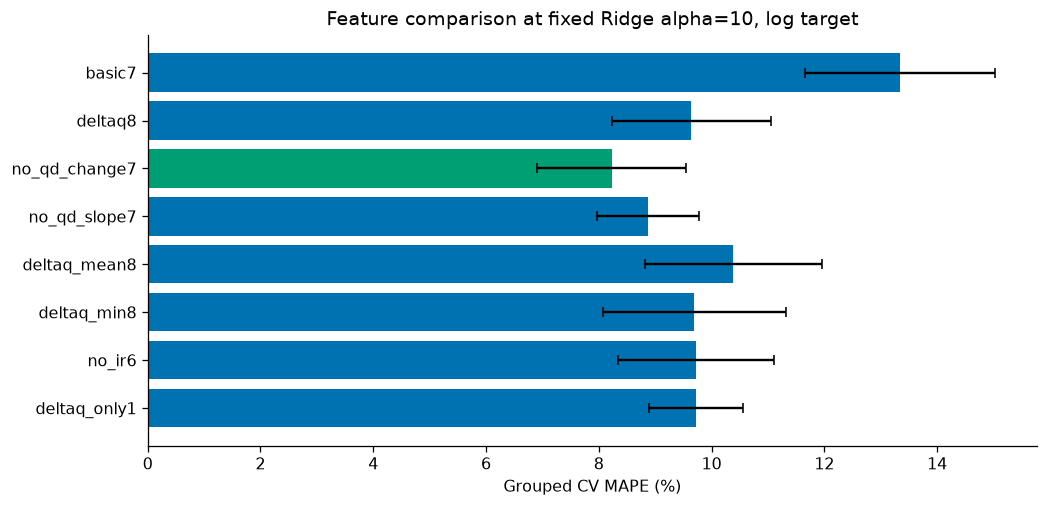

,candidate_id,target_transform,cv_mape_pct_mean,cv_mape_pct_sd
0,C037,log,8.228,1.326
1,C032,raw,8.813,1.214


In [9]:
params = cv.params.map(json.loads)
matched = cv.loc[cv.family.eq('Ridge') & cv.target_transform.eq('log')
                 & params.map(lambda p: p.get('alpha') == 10.0)].copy()
order = list(plan['features'])
ablation = matched.set_index('feature_set').loc[order].reset_index()
base_mape = ablation.loc[ablation.feature_set.eq('basic7'), 'cv_mape_pct_mean'].iloc[0]
ablation['기본7 대비 감소(%p)'] = base_mape - ablation.cv_mape_pct_mean
display(ablation[['feature_set', 'n_features', 'candidate_id', 'cv_mape_pct_mean',
                  'cv_mape_pct_sd', '기본7 대비 감소(%p)']].round(3))
fig, ax = plt.subplots(figsize=(9, 4.3), layout='constrained')
colors = ['#009E73' if name == spec['feature_set'] else '#0072B2' for name in ablation.feature_set]
ax.barh(ablation.feature_set, ablation.cv_mape_pct_mean, color=colors,
        xerr=ablation.cv_mape_pct_sd, capsize=3)
ax.invert_yaxis()
ax.set(xlabel='Grouped CV MAPE (%)', title='Feature comparison at fixed Ridge alpha=10, log target')
plt.show()
target_comparison = cv.loc[cv.family.eq('Ridge') & cv.feature_set.eq(spec['feature_set'])
                           & params.map(lambda p: p.get('alpha') == 10.0)]
display(target_comparison[['candidate_id', 'target_transform', 'cv_mape_pct_mean',
                           'cv_mape_pct_sd']].round(3))

## 7. 저장 모델의 예측과 최종 지표를 확인했습니다

네 모델 계열에서 CV가 가장 좋았던 후보를 먼저 정하고, 별도 검증용과 B2를 한 번씩 평가했습니다.
여기서는 저장 모델의 `predict()`로 그 예측을 재현하고 CSV의 지표와 비교합니다.
B2를 학습에 넣거나 모델 설정을 바꾸지는 않습니다.

In [10]:
frames = {'Valid_B1_holdout': valid, 'Test_B2': test}
reproduced_rows = []
for cid, candidate_spec in lock['specs'].items():
    model = joblib.load(OUT / 'models' / f'{cid}.joblib')
    fs = lock['feature_sets'][candidate_spec['feature_set']]
    assert np.allclose(model.named_steps['imputer'].statistics_, dev[fs].median().to_numpy())
    if 'scaler' in model.named_steps:
        assert np.allclose(model.named_steps['scaler'].mean_, dev[fs].mean().to_numpy())
    for dataset, frame in frames.items():
        pred = model.predict(frame[fs])
        saved_predictions = predictions.loc[predictions.candidate_id.eq(cid)
                                            & predictions.dataset.eq(dataset)].set_index('cell_id')
        assert np.allclose(pred, saved_predictions.loc[frame.cell_id, 'predicted'], rtol=1e-11, atol=1e-9)
        values = independent_metrics(frame.cycle_life, pred)
        saved_metrics = reported.loc[reported.candidate_id.eq(cid) & reported.dataset.eq(dataset)].iloc[0]
        assert np.allclose([values[m] for m in metric_names], saved_metrics[metric_names].to_numpy(float))
        reproduced_rows.append({'candidate_id': cid, 'family': candidate_spec['family'],
                                'dataset': dataset, 'n': len(frame), **values})
verified_metrics = pd.DataFrame(reproduced_rows)
print('4개 저장 모델 × 47개 평가 셀의 예측 및 8행 지표 재현 완료; 재학습 없음')
winner_cv = recorded.loc[winner]
winner_valid = verified_metrics.loc[verified_metrics.candidate_id.eq(winner)
                                    & verified_metrics.dataset.eq('Valid_B1_holdout')].iloc[0]
winner_test = verified_metrics.loc[verified_metrics.candidate_id.eq(winner)
                                   & verified_metrics.dataset.eq('Test_B2')].iloc[0]

4개 저장 모델 × 47개 평가 셀의 예측 및 8행 지표 재현 완료; 재학습 없음

## 8. 선택한 C037의 과제 지정 성능표입니다

과제의 세 비교 항목은 유지하고, 뺄셈과 혼동하지 않도록 **기준 → 이후**로 표시했습니다.
Gap은 **이후 MAPE - 기준 MAPE**이며, 양수이면 오차 증가를 뜻합니다.
예를 들어 Target → Test는 `55.22 - 9.10 = +46.12%p`입니다.
처음 세 값은 MAPE **%**, 뒤의 차이는 **%p(퍼센트포인트)**입니다.
`Train`은 B1 교차검증 평균이며, 개발용 데이터를 다시 예측한 오차가 아닙니다.

In [11]:
cv_mape = float(winner_cv.cv_mape_pct_mean)
valid_mape = float(winner_valid.mape_pct)
test_mape = float(winner_test.mape_pct)
gaps = {'valid_minus_cv': valid_mape-cv_mape,
        'test_minus_valid': test_mape-valid_mape,
        'test_minus_paper_9_1': test_mape-9.1}
assert all(np.isclose(value, evaluation['gaps_percentage_points'][key]) for key, value in gaps.items())
required_six_rows = pd.DataFrame([
    ['Train (Batch1 CV)', f'{cv_mape:.2f}%', f'프로토콜 GroupKFold(3) 검증 평균; SD {winner_cv.cv_mape_pct_sd:.2f}'],
    ['Valid (Batch1 Hold-out)', f'{valid_mape:.2f}%', '고정한 B1 holdout 8셀'],
    ['Test (Batch2)', f'{test_mape:.2f}%', 'B2 39셀; 모델 선택 완료 후 평가'],
    ['Gap (Train → Valid)', f'{gaps["valid_minus_cv"]:+.2f} %p', 'Valid - CV'],
    ['Gap (Valid → Test)', f'{gaps["test_minus_valid"]:+.2f} %p', 'Test - Valid'],
    ['Gap (Target → Test)', f'{gaps["test_minus_paper_9_1"]:+.2f} %p', 'Test - 논문 참고 9.1%'],
], columns=['구분', 'MAPE(%) / Gap(%p)', '비고'])
assert len(required_six_rows) == 6
display(required_six_rows)
display(verified_metrics.loc[verified_metrics.candidate_id.eq(winner),
        ['dataset', 'n', 'mape_pct', 'mae_cycles', 'rmse_cycles', 'r2']].round(3))

,구분,MAPE(%) / Gap(%p),비고
0,Train (Batch1 CV),8.23%,프로토콜 GroupKFold(3) 검증 평균; SD 1.33
1,Valid (Batch1 Hold-out),8.44%,고정한 B1 holdout 8셀
2,Test (Batch2),55.22%,B2 39셀; 모델 선택 완료 후 평가
3,Gap (Train → Valid),+0.21 %p,Valid - CV
4,Gap (Valid → Test),+46.78 %p,Test - Valid
5,Gap (Target → Test),+46.12 %p,Test - 논문 참고 9.1%


,dataset,n,mape_pct,mae_cycles,rmse_cycles,r2
2,Valid_B1_holdout,8,8.440,70.294,78.808,0.799
3,Test_B2,39,55.218,272.002,287.081,-0.713


CV와 별도 검증의 차이는 약 **+0.21%p**였지만, B2에서는 별도 검증보다 **+46.78%p** 높았습니다.
표본이 작아 이 결과만으로 과적합이 없다고 확정할 수는 없습니다.
별도 검증용 8개 중 5개는 개발용과 충전 방식도 같습니다.
B2의 **R²=-0.713**은 B2의 실제 평균 수명을 아는 상수 예측보다 제곱오차가 컸다는 뜻입니다.

논문의 참고 MAPE 9.1%와는 **+46.12%p** 차이가 났습니다.
데이터 버전·정제·수명값·분할 조건이 달라 같은 실험을 재현했다고 보지는 않았습니다.

## 9. 다른 모델의 결과도 함께 비교했습니다

단일 ΔQ를 쓴 C104 선형회귀(ln 수명)는 B2 MAPE가 28.57%로 더 낮았습니다.
다른 배치에서 단순한 모델이 더 잘 맞을 가능성을 보여 주는 관찰로 보았습니다.
하지만 미리 정한 선택 기준은 **B1 그룹 CV 평균**이므로 최종 모델은 C037로 유지했습니다.
B2 점수를 보고 모델을 바꾼 뒤 같은 B2를 독립적인 최종 평가라고 할 수는 없습니다.
단순한 모델이 실제로 더 잘 일반화하는지는 새 평가 데이터로 확인해야 합니다.

In [12]:
comparison = []
for family, cid in lock['family_winners'].items():
    candidate = lock['specs'][cid]
    scores = verified_metrics.loc[verified_metrics.candidate_id.eq(cid)].set_index('dataset')
    comparison.append({'모델군': family, '후보': cid, '특성 집합': candidate['feature_set'],
                       'y 변환': candidate['target_transform'],
                       'CV MAPE(%)': recorded.loc[cid, 'cv_mape_pct_mean'],
                       'Valid MAPE(%)': scores.loc['Valid_B1_holdout', 'mape_pct'],
                       'B2 MAPE(%)': scores.loc['Test_B2', 'mape_pct'],
                       '최종 선택': cid == winner})
family_comparison = pd.DataFrame(comparison)
display(family_comparison.round(3))
print('선택 유지:', winner, '| B2 점수로 변경:', evaluation['post_test_tuning'])

random_cv = pd.read_csv(OUT / 'random_cv_sensitivity.csv')
display(random_cv.round(3))
print(f'참고: 선택 모델의 일반 KFold 평균 MAPE {random_cv.mape_pct.mean():.2f}%')
print('일반 KFold에서는 fold별 정책 중복이', random_cv.policy_overlap_count.tolist(), '개였습니다.')
print('이 민감도 진단은 선택 기준에 쓰지 않았습니다. 그룹 CV가 항상 더 낮거나 높다는 뜻도 아닙니다.')

,모델군,후보,특성 집합,y 변환,CV MAPE(%),Valid MAPE(%),B2 MAPE(%),최종 선택
0,Dummy,C000,basic7,raw,15.591,21.262,59.321,False
1,Linear,C104,deltaq_only1,log,9.260,7.916,28.570,False
2,Ridge,C037,no_qd_change7,log,8.228,8.440,55.218,True
3,RandomForest,C112,deltaq_only1,raw,9.826,9.701,34.634,False


선택 유지: C037 | B2 점수로 변경: False


,fold,policy_overlap_count,mape_pct,mae_cycles,rmse_cycles,r2
0,1,4,12.595,98.044,117.425,0.463
1,2,3,10.020,82.592,92.863,0.557
2,3,5,7.546,54.266,59.817,0.435


참고: 선택 모델의 일반 KFold 평균 MAPE 10.05%
일반 KFold에서는 fold별 정책 중복이 [4, 3, 5] 개였습니다.
이 민감도 진단은 선택 기준에 쓰지 않았습니다. 그룹 CV가 항상 더 낮거나 높다는 뜻도 아닙니다.


## 10. 실제값과 예측값에서 오차 방향을 봤습니다

대각선 위는 수명을 **더 길게 예측한 경우**, 아래는 **더 짧게 예측한 경우**입니다.
초기 100사이클로 총수명을 예측했으므로, 달력 수명이나 현재 시점의 남은 수명과 같지는 않습니다.

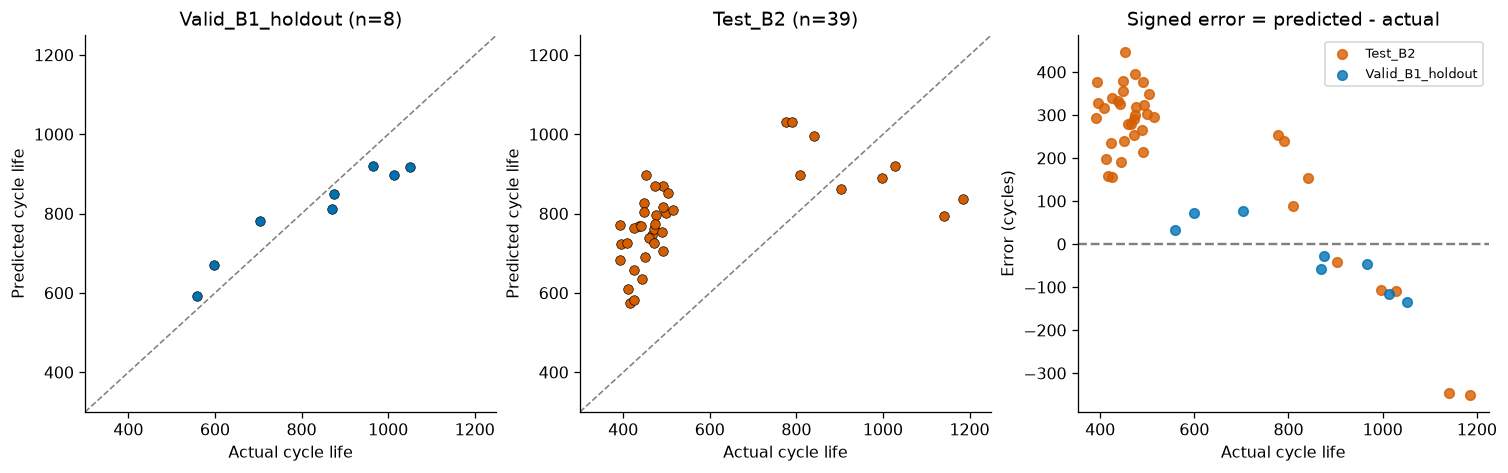

In [13]:
wp = predictions.loc[predictions.candidate_id.eq(winner)].copy()
colors = {'Valid_B1_holdout': '#0072B2', 'Test_B2': '#D55E00'}
fig, axes = plt.subplots(1, 3, figsize=(13, 4), layout='constrained')
for ax, dataset in zip(axes[:2], ['Valid_B1_holdout', 'Test_B2']):
    group = wp.loc[wp.dataset.eq(dataset)]
    ax.scatter(group.actual, group.predicted, c=colors[dataset], edgecolors='black', linewidths=.4)
    ax.plot([300, 1250], [300, 1250], '--', color='grey', linewidth=1)
    ax.set(title=f'{dataset} (n={len(group)})', xlabel='Actual cycle life', ylabel='Predicted cycle life',
           xlim=(300, 1250), ylim=(300, 1250))
for dataset, group in wp.groupby('dataset'):
    axes[2].scatter(group.actual, group.error_cycles, label=dataset, c=colors[dataset], alpha=.8)
axes[2].axhline(0, color='grey', ls='--')
axes[2].set(title='Signed error = predicted - actual', xlabel='Actual cycle life', ylabel='Error (cycles)')
axes[2].legend(fontsize=8)
plt.show()

## 11. 크게 틀린 셀의 공통점을 살펴봤습니다

아래는 선택 모델의 B2 상대오차 상위 5개입니다.
원인 설명은 관찰에 근거한 가설이며, 원인과 결과를 입증한 것은 아닙니다.
짧은 수명을 길게 예측하는 것이 주된 실패 양상이었습니다.
저항값이 있는지, 이미 본 충전 방식인지에 따라 나눠 봤습니다.
서로 겹치는 그룹이므로 각 표본 수를 더한 값이 전체 셀 수와 같지는 않습니다.

,cell_id,actual,predicted,error_cycles,ape_pct,ir_missing,policy
82,b2c29,452.0,898.01,446.01,98.67,False,5.2C(58%)-4C
61,b2c6,393.0,771.02,378.02,96.19,False,3.6C(9%)-5C
66,b2c11,449.0,827.88,378.88,84.38,False,5.2C(50%)-4.25C
89,b2c42,474.0,869.08,395.08,83.35,True,5.2C(50%)-4.25C
70,b2c15,396.0,723.62,327.62,82.73,False,3.6C(9%)-5C


,group,n,mape_pct,mae_cycles,bias_cycles
0,all,39,55.22,272.00,223.18
1,life_lt500,28,66.03,295.52,295.52
2,life_500_to1000,8,29.30,191.19,154.16
3,life_gt1000,3,23.45,267.98,-267.98
4,IR_missing,6,44.35,239.95,168.33
5,IR_present,33,57.19,277.83,233.15
6,known_policy,7,69.44,317.00,317.00
7,unseen_policy,32,52.11,262.16,202.66


B2 단수명 28개 모두 과대 예측: 평균 +295.5사이클
최대 사례: b2c29


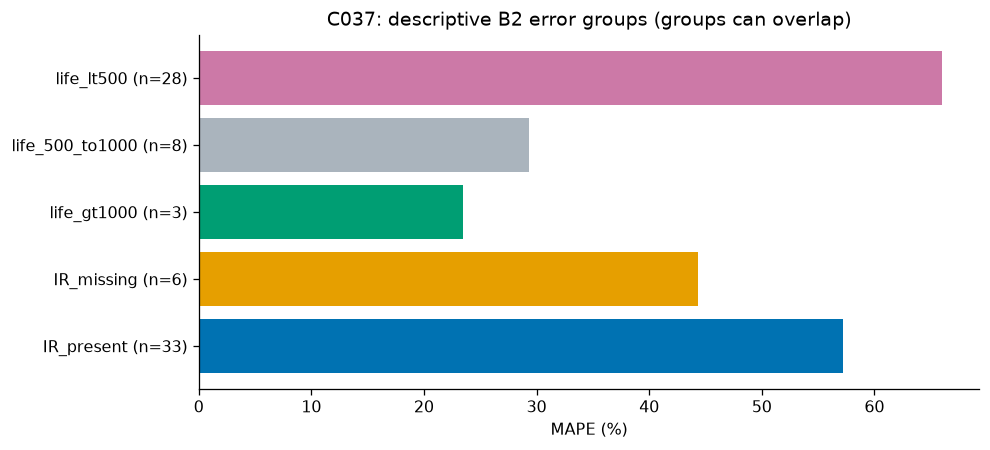

In [14]:
b2pred = wp.loc[wp.dataset.eq('Test_B2')].copy()
display(b2pred.nlargest(5, 'ape_pct')[['cell_id', 'actual', 'predicted', 'error_cycles',
            'ape_pct', 'ir_missing', 'policy']].round(2))
groups = pd.read_csv(OUT / 'subgroup_errors.csv')
b2groups = groups.loc[groups.dataset.eq('Test_B2')].copy()
display(b2groups[['group', 'n', 'mape_pct', 'mae_cycles', 'bias_cycles']].round(2))
short = b2pred.loc[b2pred.actual.lt(500)]
assert len(short) == 28 and short.error_cycles.gt(0).all()
print(f'B2 단수명 {len(short)}개 모두 과대 예측: 평균 +{short.error_cycles.mean():.1f}사이클')
print(f'최대 사례: {b2pred.nlargest(1, "ape_pct").iloc[0].cell_id}')
selected_groups = b2groups.set_index('group').loc[
    ['life_lt500', 'life_500_to1000', 'life_gt1000', 'IR_missing', 'IR_present']]
fig, ax = plt.subplots(figsize=(8.5, 3.8), layout='constrained')
ax.barh([f'{name} (n={row.n})' for name, row in selected_groups.iterrows()],
        selected_groups.mape_pct, color=['#CC79A7', '#AAB4BD', '#009E73', '#E69F00', '#0072B2'])
ax.invert_yaxis()
ax.set(title='C037: descriptive B2 error groups (groups can overlap)', xlabel='MAPE (%)')
plt.show()

단수명 28개의 MAPE는 **66.03%**, 평균적으로 더 길게 예측한 정도는 **295.5사이클**이었습니다.
가장 크게 빗나간 b2c29는 실제 452사이클을 약 898사이클로 예측했습니다.
저항값이 없는 6개의 MAPE(44.35%)는 값이 있는 33개(57.19%)보다 낮았습니다.
따라서 전체 실패를 결측값 대체 하나만으로 설명하기는 어려웠습니다.
각 그룹의 수명 구성도 달라 이 비교를 저항값 결측의 인과 효과로 보지는 않았습니다.

## 12. 입력값과 수명 분포가 얼마나 달랐는지 봤습니다

B1 개발용 수명은 534-1074사이클인데, B2 39개 중 30개는 그보다 짧고 2개는 더 길었습니다.
선형 모델은 학습한 수명 범위 밖의 숫자도 예측할 수 있지만 **그 구간의 정확성까지 보장하지는 않습니다.**
Random Forest는 학습한 수명 범위 밖으로 예측할 수 없다는 한계가 있습니다.

아래는 입력값이 개발용의 최솟값-최댓값 범위를 벗어난 셀 수입니다.
범위를 벗어났다는 사실은 분포 차이를 보여 주지만, 그 자체가 오류의 원인이거나 셀을 지울 근거는 아닙니다.
결측값은 따로 셌습니다. 배치별 상관계수 부호와 수명값의 기준이 달랐다는 점도 함께 고려했습니다.

In [15]:
shifts = pd.DataFrame(load_json('feature_range_shift.json'))
for row in shifts.itertuples():
    frame = frames[row.dataset]
    lo, hi = dev[row.feature].min(), dev[row.feature].max()
    missing_n = int(frame[row.feature].isna().sum())
    outside_n = int((frame[row.feature].notna() & ~frame[row.feature].between(lo, hi)).sum())
    assert missing_n == row.missing_n and outside_n == row.outside_range_n
display(shifts.loc[shifts.dataset.eq('Test_B2'),
                   ['feature', 'train_min', 'train_max', 'missing_n', 'outside_range_n', 'total_n']].round(5))
below = int(test.cycle_life.lt(dev.cycle_life.min()).sum())
above = int(test.cycle_life.gt(dev.cycle_life.max()).sum())
assert below == evaluation['test_below_training_target_min_n'] == 30
assert above == evaluation['test_above_training_target_max_n'] == 2
print('B2 수명의 개발 범위 미만/초과:', below, '/', above)

,feature,train_min,train_max,missing_n,outside_range_n,total_n
1,qd_cycle2,1.05378,1.09386,0,23,39
3,qd_slope_10_100,-0.00015,0.00002,0,21,39
5,ir_mean_2_100,0.01521,0.01800,6,4,39
7,ir_change_early,-0.00397,0.00021,6,4,39
9,tavg_mean_2_100,30.92150,33.89497,0,7,39
11,chargetime_mean_2_100,9.02721,12.13750,0,0,39
13,log10_deltaq_var,-4.17844,-3.36680,0,18,39


B2 수명의 개발 범위 미만/초과: 30 / 2


## 13. 선택 모델의 계수를 해석했습니다

선택 모델은 입력 X를 표준화하고 **ln(수명)**을 예측합니다.
계수는 다른 입력을 고정했을 때, 해당 입력이 개발용 표준편차 1만큼 변하는 것과 관련된 ln(수명)의 변화입니다.
`exp(계수)`는 이 모델 안에서 예측 수명이 몇 배가 되는지 나타냅니다.

이는 작은 표본과 서로 관련된 변수들에서 얻은 조건부 관계입니다.
실제 충전 조건을 바꾸면 배터리 수명이 그만큼 달라진다는 인과 효과로 보지는 않았습니다.

,feature,coefficient_log_cycles,predicted_multiplier_per_1SD
0,qd_cycle2,0.0475,1.0487
1,qd_slope_10_100,0.0281,1.0285
2,ir_mean_2_100,-0.0096,0.9904
3,ir_change_early,-0.0127,0.9874
4,tavg_mean_2_100,-0.0156,0.9845
5,chargetime_mean_2_100,0.0336,1.0342
6,log10_deltaq_var,-0.0825,0.9208


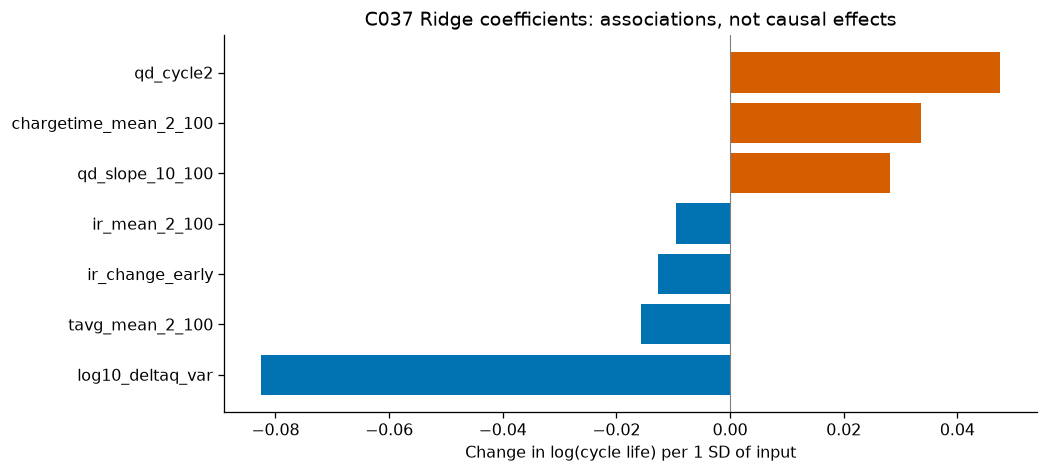

In [16]:
coefficients = pd.DataFrame({'feature': features,
                             'coefficient_log_cycles': transformer.regressor_.coef_})
coefficients['predicted_multiplier_per_1SD'] = np.exp(coefficients.coefficient_log_cycles)
recorded_coef = evaluation['interpretation']['values']
assert np.allclose(coefficients.coefficient_log_cycles, [recorded_coef[f] for f in features])
display(coefficients.round(4))
ordered = coefficients.sort_values('coefficient_log_cycles')
fig, ax = plt.subplots(figsize=(9, 4), layout='constrained')
ax.barh(ordered.feature, ordered.coefficient_log_cycles,
        color=['#0072B2' if v < 0 else '#D55E00' for v in ordered.coefficient_log_cycles])
ax.axvline(0, color='grey', linewidth=.7)
ax.set(title='C037 Ridge coefficients: associations, not causal effects',
       xlabel='Change in log(cycle life) per 1 SD of input')
plt.show()

## 14. ESS 활용의 한계와 개선 방향을 정리했습니다

B1 내부에서는 평균 예측보다 오차가 줄었지만, B2에서는 충분히 잘 맞지 않았습니다.
특히 짧은 수명을 길게 예측해 이 결과만으로 교체 시점이나 안전 운전을 결정하기는 어렵습니다.
총사이클 수 예측을 남은 일수나 실제 교체 비용 절감으로 바로 바꿀 수도 없습니다.

실제 활용을 검토하기 전에 다음을 확인하겠습니다.

1. 같은 수명값 기준과 초기 측정 조건을 가진 여러 배치에서 평가하겠습니다.
2. 과대예측과 입력 범위 이탈을 점검해, 추가 시험이 필요한 셀을 찾는 보조 정보로 검토하겠습니다.
3. 배터리 종류·온도·운영 부하·충전 방식·품질 이력과 예측 불확실성을 함께 확인하겠습니다.
4. 단일 ΔQ, 저항 제외, 배치별 관계 차이는 새 개발 데이터에서 비교하겠습니다.
   이미 본 B2를 보고 바꾼 실험은 후속 탐색으로 구분하겠습니다.

남은 한계는 개발용 28개·별도 검증용 8개의 작은 표본, 같은 CV에서 여러 후보를 고른 영향,
별도 검증용의 충전 방식 일부 중복, DAY 1에서 평가 배치도 관찰한 점,
B1/B2의 수명값·분포·버전 차이, 불완전한 기록의 제외, 해독하지 못한 물리 셀 식별자입니다.
DAY 1에서 계획했던 품질 기준·종료 용량 판정 기준 변경에 따른 모델 성능 비교는 수행하지 않았습니다.
실제 ESS 운영에서 검증하지 않았으며, Batch 3 추가 모델 평가도 수행하지 않았습니다.

## 15. 실행 방법입니다

**저장된 결과 확인:** 이 노트북은 저장된 모델로 예측·지표를 확인하고,
마지막 셀에서 데이터·모델·선택 기록이 그대로인지 점검합니다. 원본 MAT 파일은 필요하지 않습니다.
README의 환경 설정을 마친 뒤, 저장소 최상위에서 아래 명령으로도 검증할 수 있습니다.

```bash
.venv/bin/python src/verify_day2.py
```

검증 스크립트는 재학습 없이 저장 결과를 확인하고 `results/day2/validation.json`을 갱신합니다.

**정제 데이터로 재학습:** 아래 명령은 새 임시 폴더에 코드와 입력 파일만 복사해 학습합니다.
기존 `results/day2/`를 복사하거나 삭제하지 않으므로 원래 모델과 결과가 보존됩니다.
README의 환경 설정을 마친 뒤, macOS 저장소 최상위에서 블록 전체를 순서대로 실행해 주세요.

```bash
project_dir="$PWD"
day2_python="$project_dir/.venv/bin/python"
retrain_dir="$(mktemp -d "${TMPDIR:-/tmp}/battery-day2-retrain.XXXXXX")"
mkdir -p "$retrain_dir/data" "$retrain_dir/results" "$retrain_dir/references"
cp -R "$project_dir/src" "$retrain_dir/src"
cp -R "$project_dir/data/processed" "$retrain_dir/data/processed"
cp "$project_dir/results/split_assignment.csv" "$retrain_dir/results/"
cp "$project_dir/references/baseline_batch12_splits.csv" "$retrain_dir/references/"

"$day2_python" "$retrain_dir/src/train_day2.py" --phase select
"$day2_python" "$retrain_dir/src/train_day2.py" --phase evaluate
"$day2_python" "$retrain_dir/src/verify_day2.py"
```

새 결과는 `$retrain_dir/results/day2/`에 저장됩니다. 학습에 필요한 입력은
`data/processed/cells_analysis.csv`와 `results/split_assignment.csv`입니다.
학습 후 검증에서 초기 특성과 기존 분할도 확인할 수 있도록 정제 데이터 폴더와
`references/baseline_batch12_splits.csv`를 함께 복사합니다.

`select`는 계획 저장, 개발 CV 후보 선택, 개발용 28개 학습과 선택 기록 고정을 수행합니다.
`evaluate`는 고정 모델로 별도 검증용과 B2를 평가합니다.
해당 단계의 결과가 이미 있으면 스크립트가 중단하므로, 다시 실행할 때도 새 임시 폴더를 만드세요.
이 노트북은 재학습 명령을 자동 실행하지 않습니다.

**원본 MAT부터 재생성:** 세 파일의 정확한 이름·위치와
`prepare_data.py → analyze.py → supplement_day1.py` 실행 순서는
[데이터 안내](../data/DATA_SOURCE.md)를 참고해 주세요.
구현은 `src/train_day2.py`, 과제 기준은 `docs/notion_day2_requirements.txt`에 정리했습니다.

In [17]:
after_hashes = {relative: sha(ROOT / relative) for relative in before_hashes}
assert after_hashes == before_hashes
assert winner == lock['winner_id'] == evaluation['winner_id'] == 'C037'
assert len(required_six_rows) == 6
assert evaluation['post_test_tuning'] is False
print('완료: 모든 검증 통과')
print('데이터·선택 기록·저장 모델 변경 없음 / 재학습 없음 / B3 모델 평가 없음')
print(f'선택 모델 {winner}: CV {cv_mape:.2f}%, Valid {valid_mape:.2f}%, B2 {test_mape:.2f}%')

완료: 모든 검증 통과
데이터·선택 기록·저장 모델 변경 없음 / 재학습 없음 / B3 모델 평가 없음
선택 모델 C037: CV 8.23%, Valid 8.44%, B2 55.22%
